# ARC-AGI — Category Explorer (Colab)

Browse all 400 training tasks by human-decision-tree category.  
Where a rule-based solver exists, predictions are shown alongside the expected output.

**Run order:** Cell 1 (setup) → Cell 2 (classify) → then any of Cells 3–5 in any order.

In [1]:
# ── Cell 1: Setup — works in Colab and locally ───────────────────────────────
import os, io, subprocess, urllib.request, zipfile, sys
from pathlib import Path

IN_COLAB    = 'google.colab' in sys.modules
GITHUB_USER = 'rodehyde'
REPO        = 'arc-agi-solver'

if IN_COLAB:
    REPO_DIR = f'/content/{REPO}'
    if not os.path.isdir(REPO_DIR):
        subprocess.run(['git', 'clone', f'https://github.com/{GITHUB_USER}/{REPO}.git', REPO_DIR],
                       check=True)
    else:
        result = subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'],
                                capture_output=True, text=True)
        print(result.stdout or result.stderr)
    os.chdir(REPO_DIR)
else:
    # Local: notebook lives in notebooks/, repo root is one level up
    REPO_DIR = str(Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks'
                   else Path(os.getcwd()))
    os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f'Working directory: {os.getcwd()}')
print(subprocess.run(['git', 'log', '--oneline', '-3'], capture_output=True, text=True).stdout)

train_dir = Path('data/training')
if not train_dir.exists() or len(list(train_dir.glob('*.json'))) < 400:
    print('Downloading ARC-AGI training data...')
    with urllib.request.urlopen(
        'https://github.com/fchollet/ARC-AGI/archive/refs/heads/master.zip') as r:
        raw = r.read()
    train_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        for m in zf.namelist():
            if 'data/training/' in m and m.endswith('.json'):
                (train_dir / Path(m).name).write_bytes(zf.read(m))
print(f'Training tasks available: {len(list(train_dir.glob("*.json")))}')

Working directory: /Users/rodhyde/Documents/GitHub/arc-agi-solver
c9b4d2e Fix notebook Cell 1 to run locally and in Colab
fcc5926 Update step 3 of ARC protocol and add grid dimensions to notebook
51f1124 Add 7 new EXTRACT_UNIQUE_SHAPE sub-category detectors

Training tasks available: 400


In [ ]:
# ── Cell 2: Classify all tasks and show category summary ─────────────────────
# NOTE: re-run this cell after every git pull — reloads all scripts including
# display.py, so changes to show_task() take effect without reopening the notebook.
import importlib, sys
from collections import defaultdict
from pathlib import Path

# Force-reload all scripts.* modules in dependency order
for mod_name in list(sys.modules):
    if mod_name.startswith('scripts.'):
        importlib.reload(sys.modules[mod_name])

from scripts.human_tree import load_task as ht_load, classify
from scripts.solvers    import load_task
from scripts.display    import show_task

# ── Quick self-check ──────────────────────────────────────────────────────────
_sample = load_task('00d62c1b')
_te     = _sample['test'][0]
assert _te['output'] is not None, \
    "Test output is None — training data may be missing outputs. Re-run Cell 1."
print(f"Self-check OK: test output present (shape {_te['output'].shape})")

# ── Classify all 400 tasks ────────────────────────────────────────────────────
task_ids = sorted(p.stem for p in Path('data/training').glob('*.json'))
by_cat   = defaultdict(list)
for tid in task_ids:
    cat = classify(ht_load(tid))
    by_cat[cat].append(tid)

print(f'Classified {len(task_ids)} tasks into {len(by_cat)} categories\n')
print(f'{"Category":<35} {"Count":>5}  Sample IDs')
print('-' * 80)
for cat, ids in sorted(by_cat.items(), key=lambda x: -len(x[1])):
    sample = '  ' + '  '.join(ids[:4]) + ('...' if len(ids) > 4 else '')
    print(f'  {cat:<33} {len(ids):>5}{sample}')

FILL_REGIONS: 4 tasks  |  showing index 0 → 00d62c1b


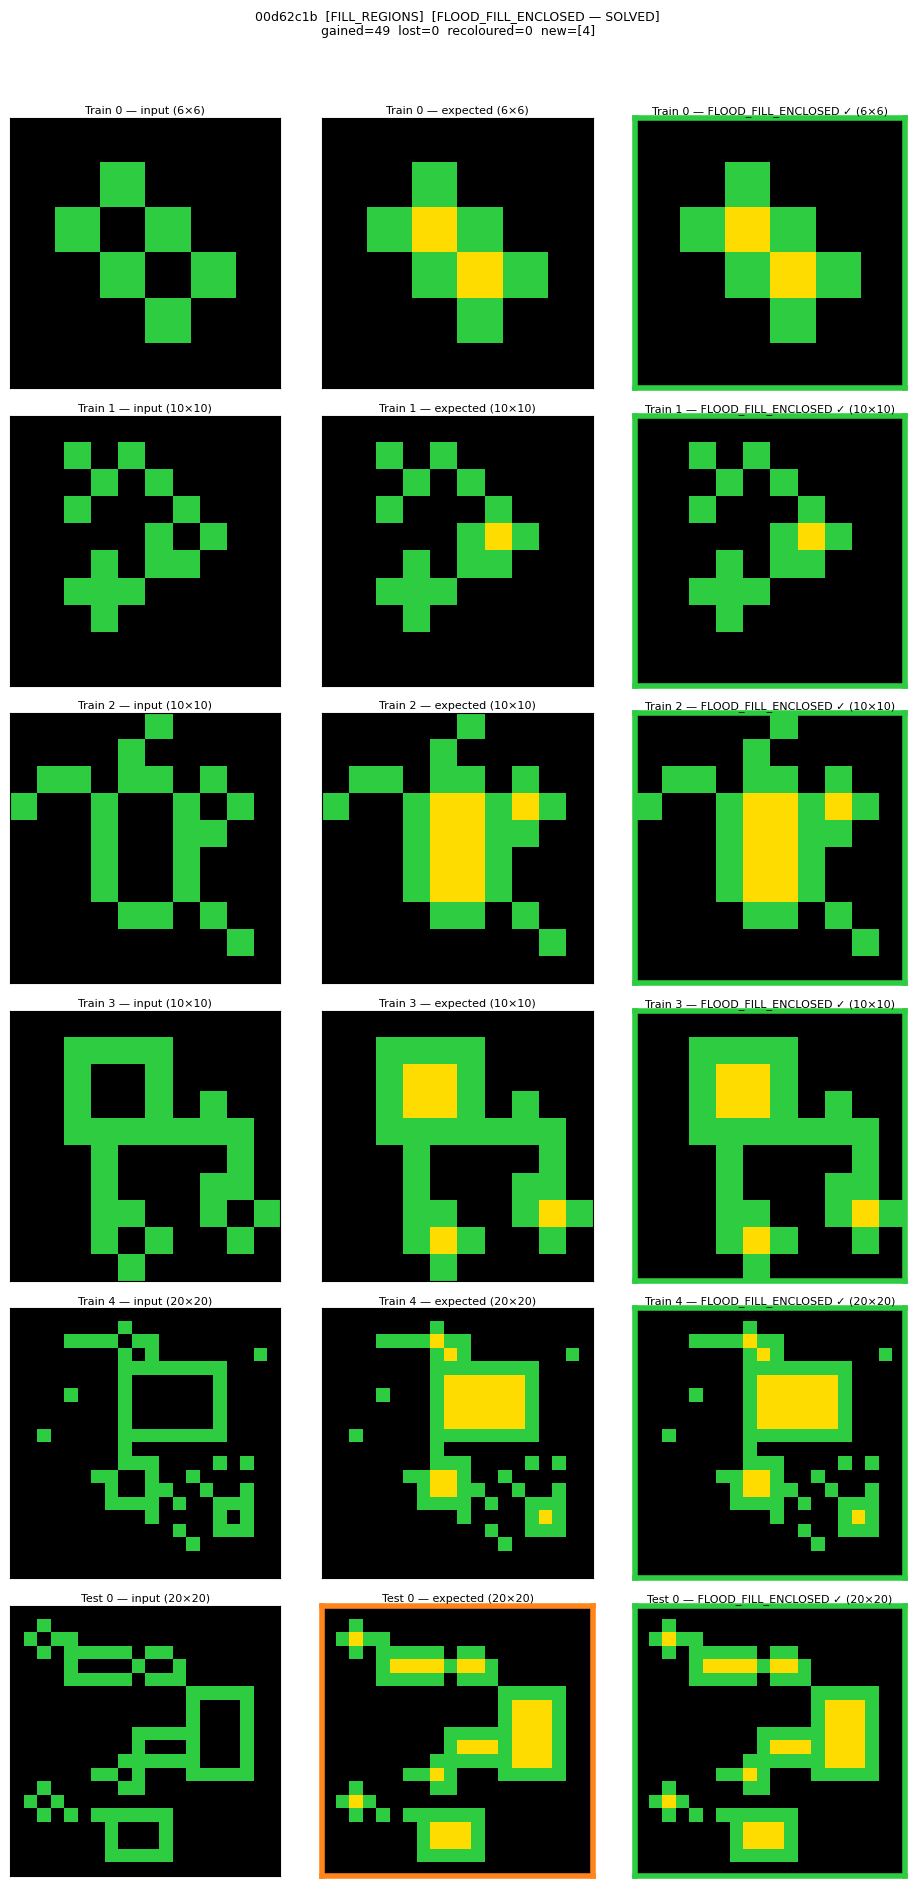

In [3]:
# ── Cell 3: Browse a category one task at a time ─────────────────────────────
# Change CATEGORY and IDX then re-run.
# If the category has a solver, a third column shows the prediction.

CATEGORY = 'FILL_REGIONS'   # ← any category from the table above
IDX      = 0                # ← 0-based index within the category

ids = by_cat[CATEGORY]
print(f'{CATEGORY}: {len(ids)} tasks  |  showing index {IDX} → {ids[IDX]}')
show_task(ids[IDX])

FILL_REGIONS: 4 tasks



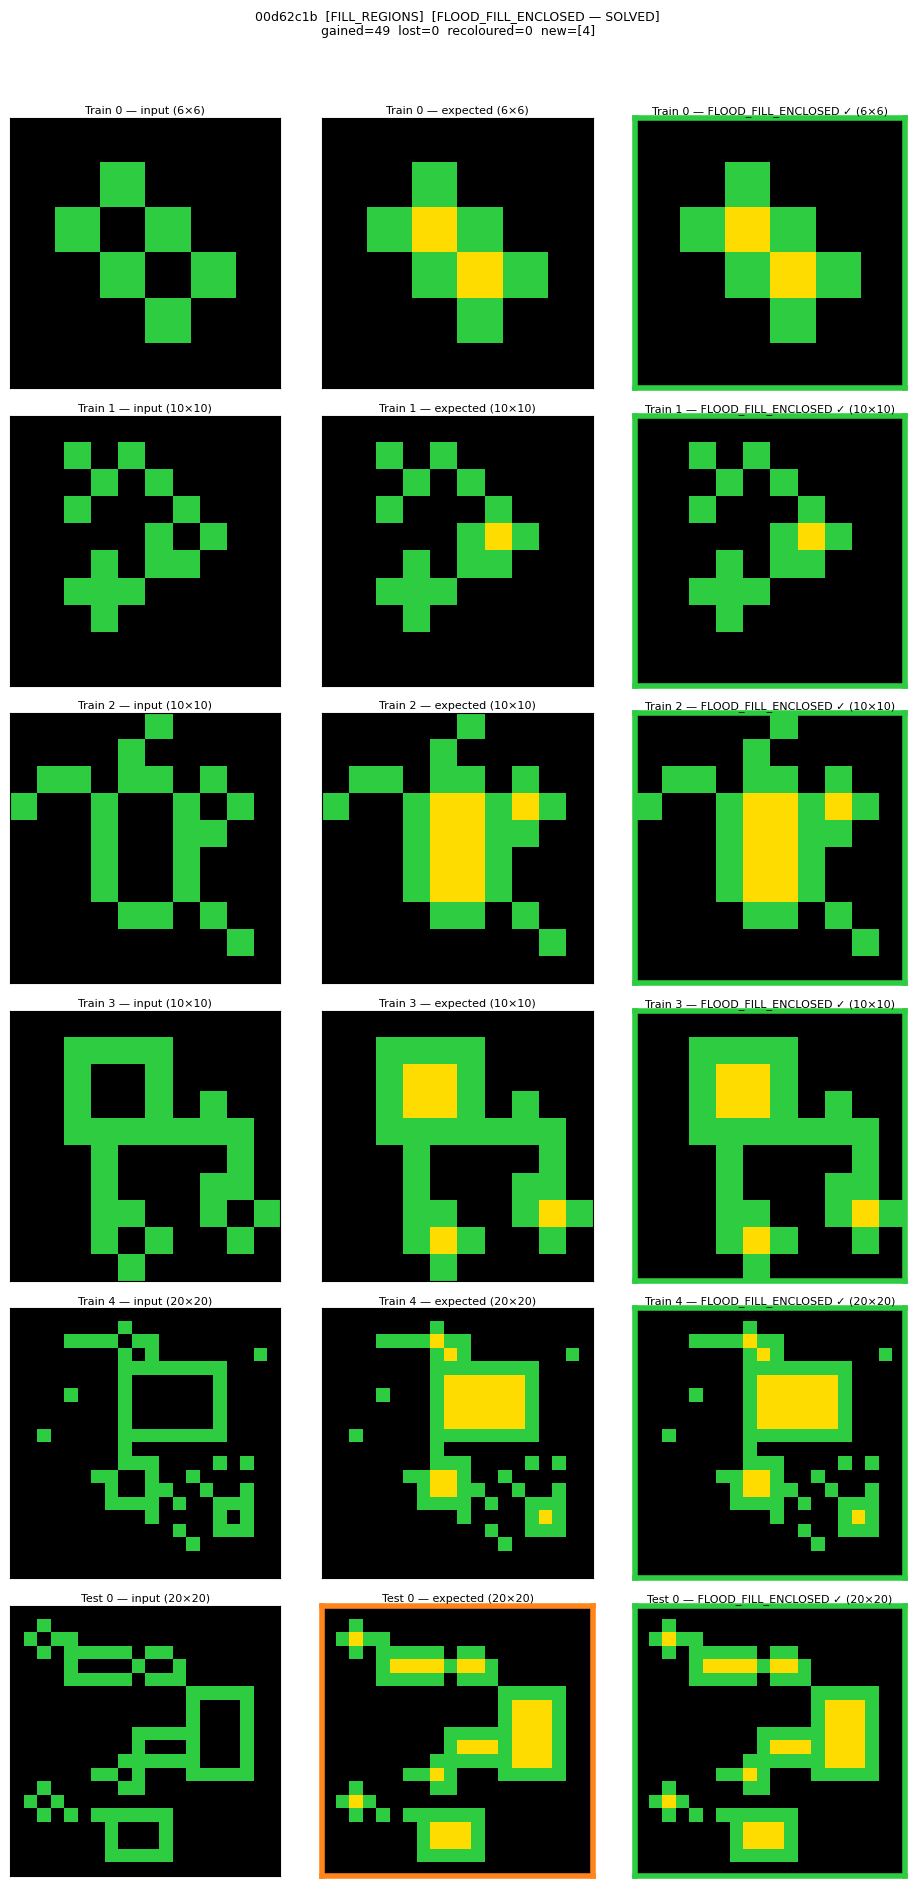

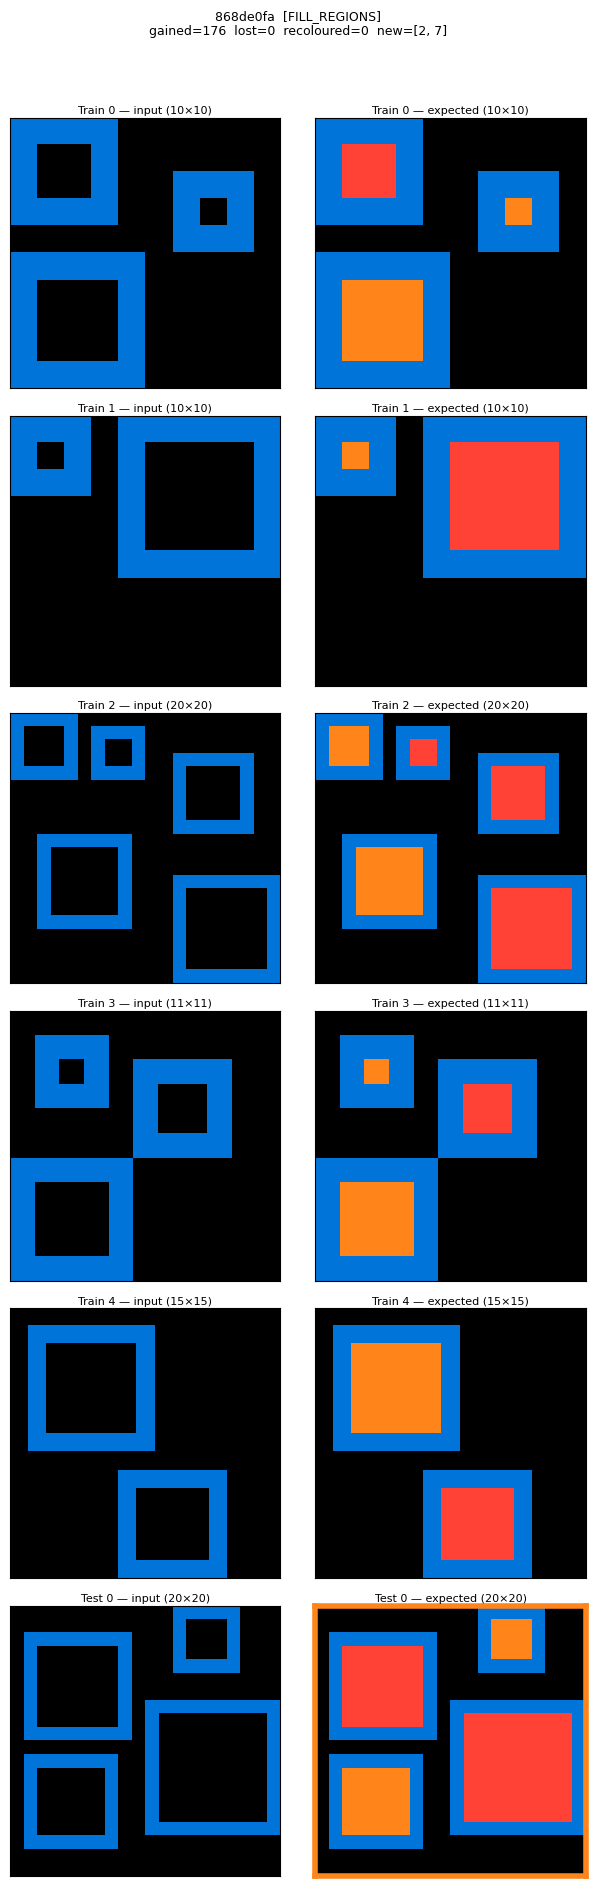

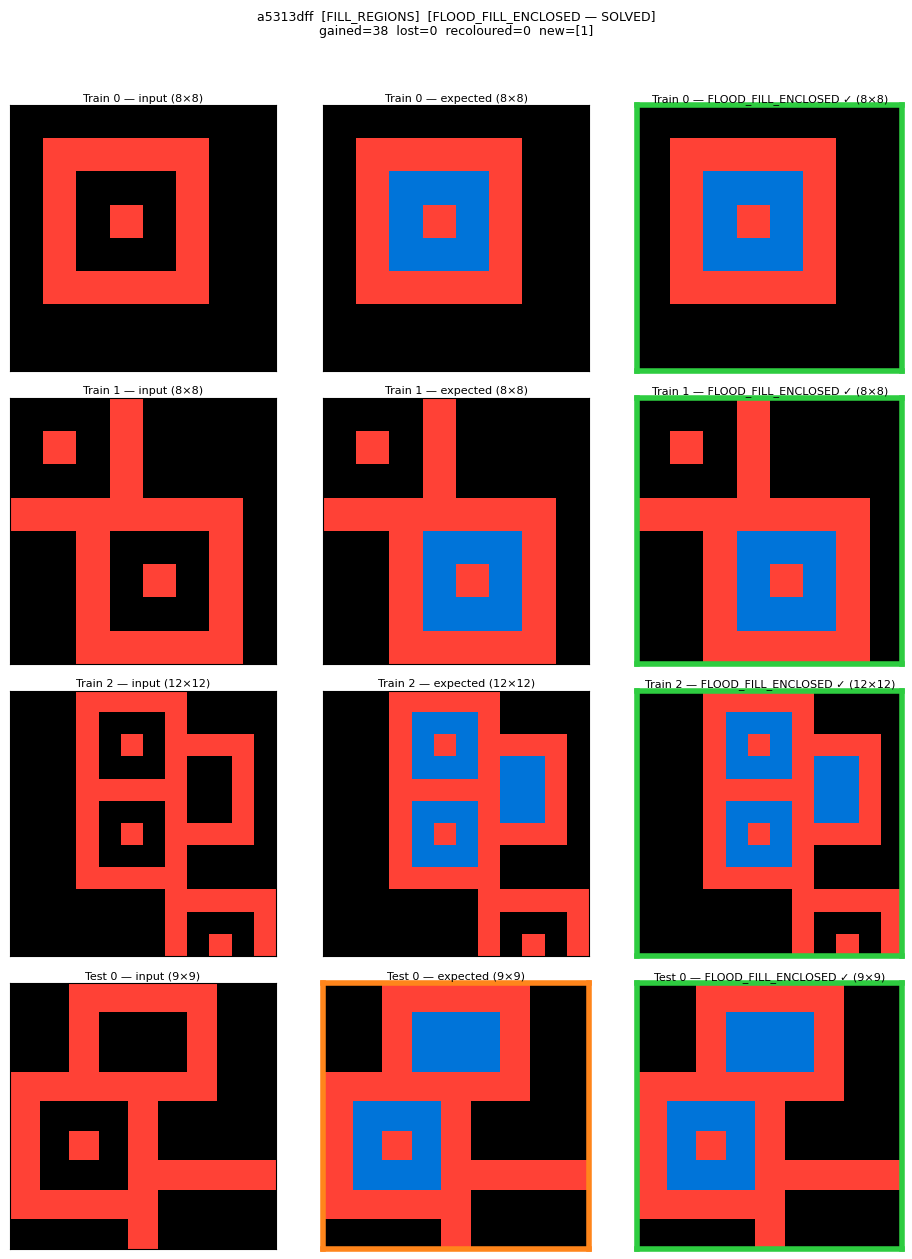

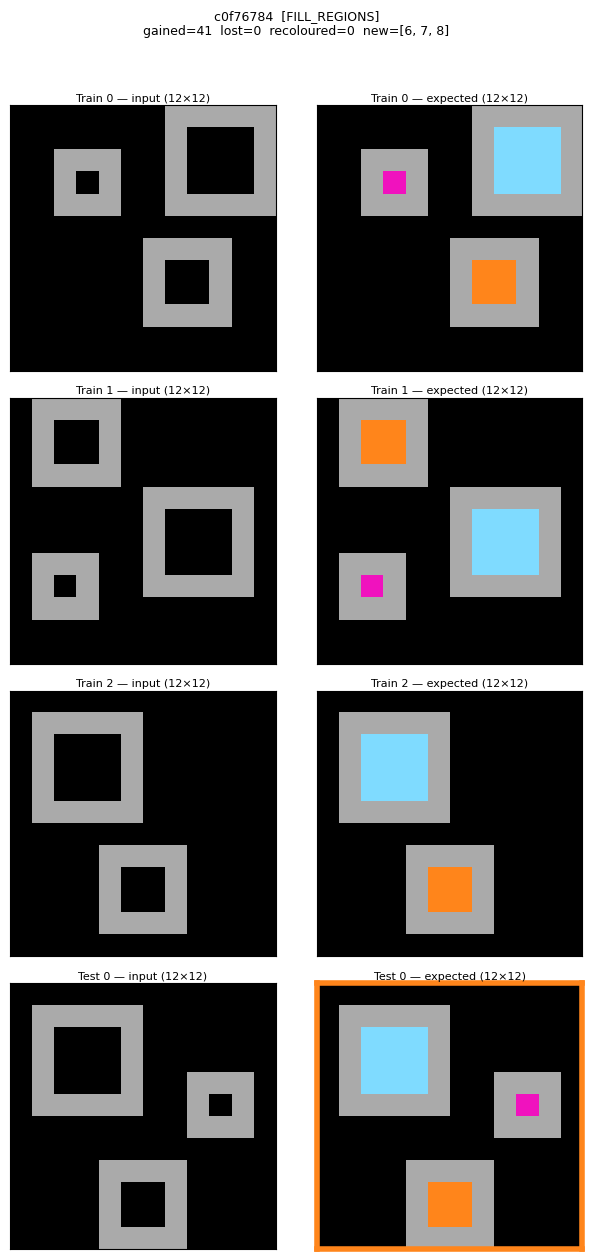

In [4]:
# ── Cell 4: Show all tasks in a category ─────────────────────────────────────
# Useful for scanning an entire category at once.
# Set SHOW_PREDICTIONS=False to speed things up if no solver exists yet.

CATEGORY         = 'FILL_REGIONS'   # ← category to dump
SHOW_PREDICTIONS = True             # ← False = faster, no prediction column

ids = by_cat[CATEGORY]
print(f'{CATEGORY}: {len(ids)} tasks\n')
for tid in ids:
    show_task(tid, show_prediction=SHOW_PREDICTIONS)

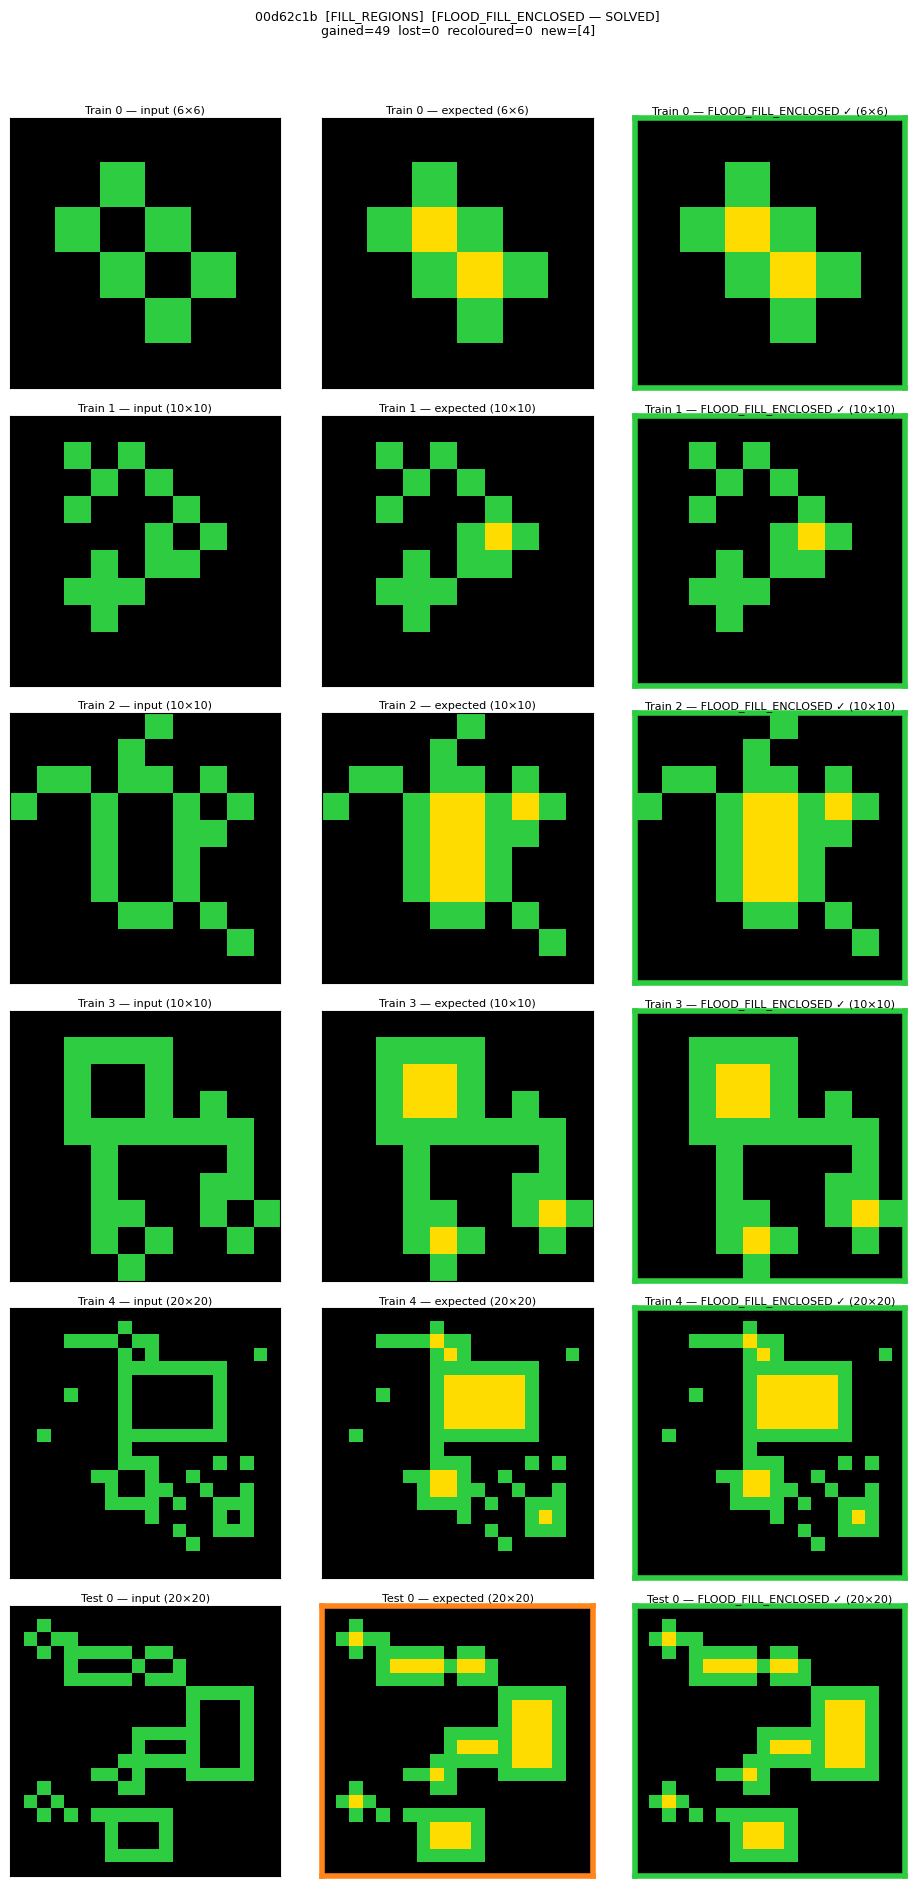

In [5]:
# ── Cell 5: Inspect a specific task by ID ────────────────────────────────────

TASK_ID = '00d62c1b'   # ← paste any 8-character task ID

show_task(TASK_ID)